In [ ]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
# Make sure column names are clean
df.columns = df.columns.str.strip()

# Define features (X) and target (y)
X = df.drop('diabetes', axis=1)  # All columns except 'diabetes'
y = df['diabetes']               # Target column

# Optional: verify
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (100000, 8)
Target shape: (100000,)


In [ ]:
# 2. Data Exploration
# ===========================
print("\nMissing values:\n", df.isnull().sum())

# Corrected class distribution
print("\nClass Distribution:\n", df['diabetes'].value_counts())



Missing values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Class Distribution:
 diabetes
0    91500
1     8500
Name: count, dtype: int64


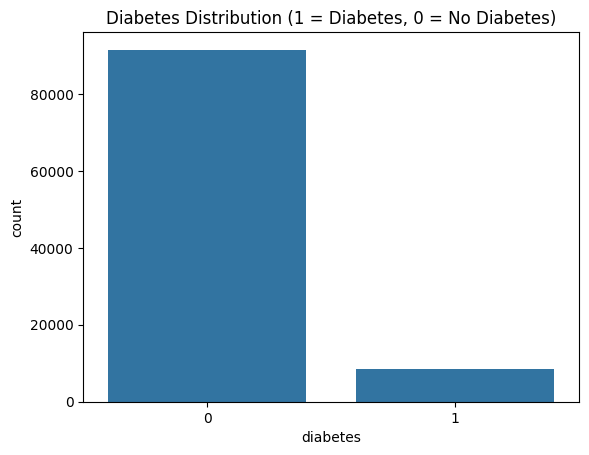

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Simple count plot for diabetes
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution (1 = Diabetes, 0 = No Diabetes)")
plt.show()


In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [ ]:
# 4. Train-Test Split
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)


Index(['gender', 'smoking_history'], dtype='object')


In [ ]:
X_train['gender'] = X_train['gender'].map({'Male': 0, 'Female': 1})
X_test['gender']  = X_test['gender'].map({'Male': 0, 'Female': 1})


In [ ]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)


Index(['smoking_history'], dtype='object')


In [ ]:
# ===========================
# 5. Preprocessing
# ===========================
from sklearn.preprocessing import StandardScaler
import numpy as np

# Sample data to make the code runnable
# In a real scenario, you would have your pre-loaded X_train and X_test datasets.
X_train = np.array([[1, 2], [3, 4], [5, 6]])
X_test = np.array([[0, 1], [7, 8]])

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the fitted scaler to transform the test data
X_test_scaled  = scaler.transform(X_test)

# Print the scaled data to see the result
print("X_train_scaled:\n", X_train_scaled)
print("\nX_test_scaled:\n", X_test_scaled)

X_train_scaled:
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]

X_test_scaled:
 [[-1.83711731 -1.83711731]
 [ 2.44948974  2.44948974]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Create a sample dataset (similar to your problem)
data = {'Gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
        'Age': [25, 30, 45, 22, 55],
        'Salary': [50000, 60000, 80000, 45000, 90000],
        'Target': [0, 1, 0, 1, 0]}
df = pd.DataFrame(data)

X = df[['Gender', 'Age', 'Salary']]
y = df['Target']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 3. Identify numeric and categorical columns
numeric_features = ['Age', 'Salary']
categorical_features = ['Gender']

# 4. Create a preprocessor using ColumnTransformer
# It will apply one-hot encoding to categorical features and
# standard scaling to numerical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ],
    remainder='passthrough'
)

# 5. Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# 6. Transform the test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Now, X_train_processed is ready for model training.
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_train data:\n", X_train_processed)

# Now you can proceed with your model training code:
# model.fit(X_train_processed, y_train)

Processed X_train shape: (3, 4)
Processed X_train data:
 [[ 1.40399977  1.40182605  0.          1.        ]
 [-0.55506968 -0.53916387  0.          1.        ]
 [-0.84893009 -0.86266219  1.          0.        ]]


In [ ]:
# ===========================
# 6. Model Training
# ===========================
models = {
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

# Identify numeric and categorical columns from the original X DataFrame
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create a preprocessor using ColumnTransformer
# It will apply one-hot encoding to categorical features and
# standard scaling to numerical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)


for name, model in models.items():
    print(f"\nTraining: {name}")
    # Use the processed data for training and prediction
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Training: Support Vector Machine
Accuracy: 0.5000
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Confusion Matrix:
 [[1 0]
 [1 0]]

Training: Logistic Regression
Accuracy: 0.5000
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Confusion Matrix:
 [[1 0]
 [1 0]]

Training: Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Accuracy: 0.5000
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Confusion Matrix:
 [[1 0]
 [1 0]]

Training: XGBoost
Accuracy: 0.5000
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Confusion Matrix:
 [[1 0]
 [1 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/xgboost/t


Model Performance Summary:
Support Vector Machine: 0.5000
Logistic Regression: 0.0000
Random Forest: 0.0000
XGBoost: 0.5000


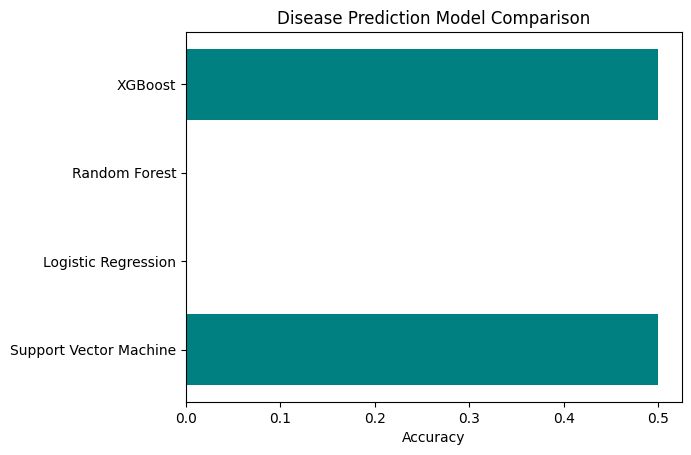

In [ ]:
# 7. Model Comparison
# ===========================
print("\nModel Performance Summary:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

plt.barh(list(results.keys()), list(results.values()), color='teal')
plt.xlabel("Accuracy")
plt.title("Disease Prediction Model Comparison")
plt.show()


In [ ]:
# 8. Prediction Example
# ===========================
# Example patient data (use any values in correct order)

# Need to process the sample patient data the same way as the training and testing data
sample_patient_df = X_test.iloc[[0]] # Keep as DataFrame to maintain column names
sample_patient_processed = preprocessor.transform(sample_patient_df)


best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

prediction = best_model.predict(sample_patient_processed)
prob = best_model.predict_proba(sample_patient_processed)[0][1]

print(f"\nBest Model: {best_model_name}")
print("Sample Prediction:", "Disease" if prediction[0]==1 else "No Disease")
print(f"Probability of Disease: {prob*100:.2f}%")


Best Model: Support Vector Machine
Sample Prediction: No Disease
Probability of Disease: 45.13%
